<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/ml_projects/recommendation_system/experiment_recommendation_system_embeddings_bias_ranking_bpr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# LEVEL 1: BASIC RECOMMENDATION SYSTEM
# Using embeddings (from scratch idea)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------------
# 1. Dummy Data
# -------------------------------
# Users (0,1,2,3)
# Items (0,1,2,3,4)

# Each tuple = (user, item, rating)
data = [
    (0, 0, 5),
    (0, 1, 3),
    (1, 0, 4),
    (1, 2, 2),
    (2, 1, 4),
    (2, 3, 5),
    (3, 2, 3),
    (3, 4, 4)
]

users = torch.tensor([d[0] for d in data])
items = torch.tensor([d[1] for d in data])
ratings = torch.tensor([d[2] for d in data], dtype=torch.float32)

num_users = 4
num_items = 5

# -------------------------------
# 2. Model
# -------------------------------
class Recommender(nn.Module):
    def __init__(self, num_users, num_items, embed_size=8):
        super().__init__()

        # Each user gets a vector
        self.user_embedding = nn.Embedding(num_users, embed_size)

        # Each item gets a vector
        self.item_embedding = nn.Embedding(num_items, embed_size)

    def forward(self, user, item):
        # Get user vector
        user_vec = self.user_embedding(user)

        # Get item vector
        item_vec = self.item_embedding(item)

        # Dot product → similarity
        # High value = strong match
        return (user_vec * item_vec).sum(dim=1)


model = Recommender(num_users, num_items)

# -------------------------------
# 3. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(50):
    optimizer.zero_grad()

    preds = model(users, items)

    loss = loss_fn(preds, ratings)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 10.2214
Epoch 10, Loss: 5.4510
Epoch 20, Loss: 2.6795
Epoch 30, Loss: 1.3050
Epoch 40, Loss: 0.6492


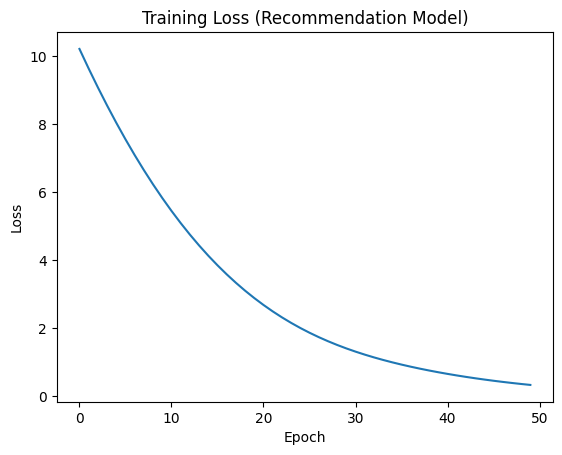

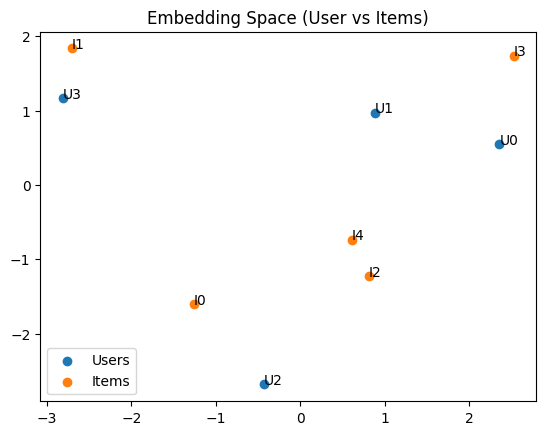

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1. Loss Curve
# -------------------------------
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Recommendation Model)")
plt.show()


# -------------------------------
# 2. Embedding Space Visualization
# -------------------------------
# We reduce embeddings to 2D to see relationships

from sklearn.decomposition import PCA

user_emb = model.user_embedding.weight.detach().numpy()
item_emb = model.item_embedding.weight.detach().numpy()

pca = PCA(n_components=2)

user_2d = pca.fit_transform(user_emb)
item_2d = pca.fit_transform(item_emb)

plt.figure()

# Plot users
plt.scatter(user_2d[:,0], user_2d[:,1], label="Users")

# Plot items
plt.scatter(item_2d[:,0], item_2d[:,1], label="Items")

for i, txt in enumerate(range(len(user_2d))):
    plt.annotate(f"U{i}", (user_2d[i][0], user_2d[i][1]))

for i, txt in enumerate(range(len(item_2d))):
    plt.annotate(f"I{i}", (item_2d[i][0], item_2d[i][1]))

plt.title("Embedding Space (User vs Items)")
plt.legend()
plt.show()

In [ ]:
# ============================================
# LEVEL 2: RECOMMENDER WITH BIAS (REALISTIC)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------------
# 1. Same Data
# -------------------------------
data = [
    (0, 0, 5),
    (0, 1, 3),
    (1, 0, 4),
    (1, 2, 2),
    (2, 1, 4),
    (2, 3, 5),
    (3, 2, 3),
    (3, 4, 4)
]

users = torch.tensor([d[0] for d in data])
items = torch.tensor([d[1] for d in data])
ratings = torch.tensor([d[2] for d in data], dtype=torch.float32)

num_users = 4
num_items = 5

# -------------------------------
# 2. Improved Model
# -------------------------------
class RecommenderV2(nn.Module):
    def __init__(self, num_users, num_items, embed_size=8):
        super().__init__()

        # Embeddings (same as before)
        self.user_embedding = nn.Embedding(num_users, embed_size)
        self.item_embedding = nn.Embedding(num_items, embed_size)

        # 🔥 NEW: Bias terms
        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)

        # Global average rating
        self.global_bias = nn.Parameter(torch.tensor(0.0))

    def forward(self, user, item):

        # Get embeddings
        user_vec = self.user_embedding(user)
        item_vec = self.item_embedding(item)

        # Dot product interaction
        interaction = (user_vec * item_vec).sum(dim=1)

        # Get biases
        user_b = self.user_bias(user).squeeze()
        item_b = self.item_bias(item).squeeze()

        # Final prediction
        return interaction + user_b + item_b + self.global_bias


model = RecommenderV2(num_users, num_items)

# -------------------------------
# 3. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

loss_history_v2 = []

for epoch in range(50):
    optimizer.zero_grad()

    preds = model(users, items)

    loss = loss_fn(preds, ratings)

    loss.backward()
    optimizer.step()

    loss_history_v2.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 41.2380
Epoch 10, Loss: 27.2975
Epoch 20, Loss: 17.0989
Epoch 30, Loss: 10.0094
Epoch 40, Loss: 5.3650


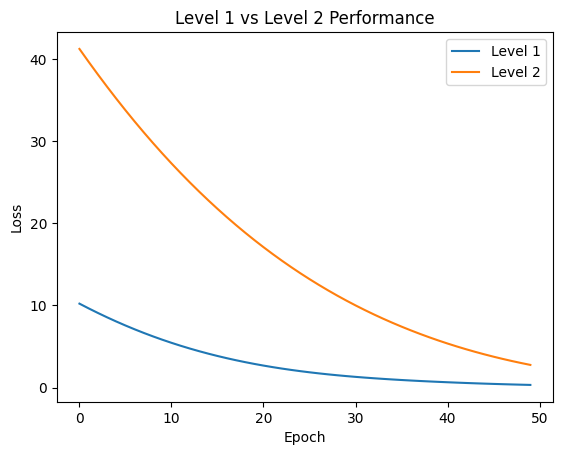

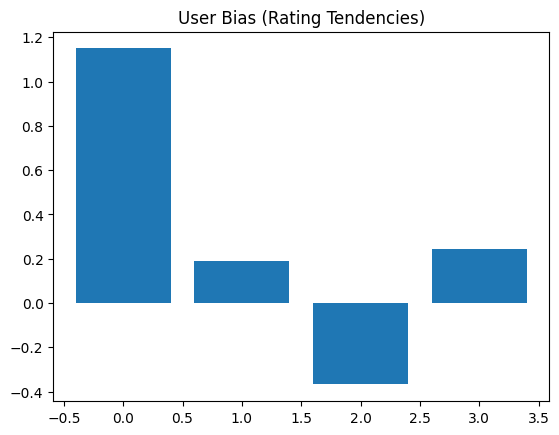

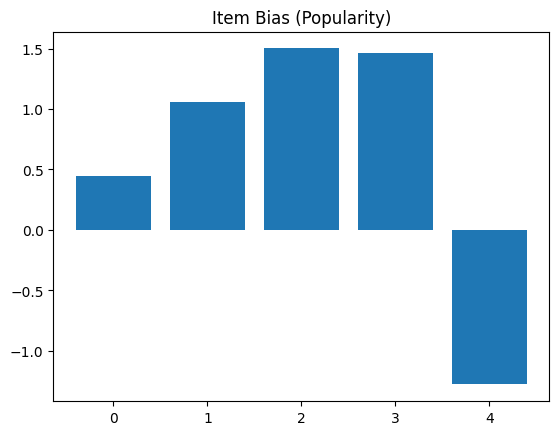

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Compare Loss Curves
# -------------------------------
plt.figure()

plt.plot(loss_history, label="Level 1")
plt.plot(loss_history_v2, label="Level 2")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Level 1 vs Level 2 Performance")
plt.legend()
plt.show()


# -------------------------------
# 2. Bias Distribution
# -------------------------------
user_bias = model.user_bias.weight.detach().numpy().flatten()
item_bias = model.item_bias.weight.detach().numpy().flatten()

plt.figure()
plt.bar(range(len(user_bias)), user_bias)
plt.title("User Bias (Rating Tendencies)")
plt.show()

plt.figure()
plt.bar(range(len(item_bias)), item_bias)
plt.title("Item Bias (Popularity)")
plt.show()

In [ ]:
# ============================================
# LEVEL 3: RANKING-BASED RECOMMENDER
# (Pairwise learning)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------------
# 1. Create Pairwise Data
# -------------------------------
# (user, positive_item, negative_item)

pairs = [
    (0, 0, 1),  # user 0 prefers item 0 over 1
    (1, 0, 2),
    (2, 3, 1),
    (3, 4, 2)
]

users = torch.tensor([p[0] for p in pairs])
pos_items = torch.tensor([p[1] for p in pairs])
neg_items = torch.tensor([p[2] for p in pairs])

num_users = 4
num_items = 5

# -------------------------------
# 2. Model (same embeddings)
# -------------------------------
class RecommenderV3(nn.Module):
    def __init__(self, num_users, num_items, embed_size=8):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embed_size)
        self.item_embedding = nn.Embedding(num_items, embed_size)

    def forward(self, user, item):
        user_vec = self.user_embedding(user)
        item_vec = self.item_embedding(item)

        # Score = similarity
        return (user_vec * item_vec).sum(dim=1)


model = RecommenderV3(num_users, num_items)

# -------------------------------
# 3. Ranking Loss (BPR Loss)
# -------------------------------
def bpr_loss(pos_scores, neg_scores):
    """
    We want:
    pos_score > neg_score

    So:
    maximize (pos - neg)
    """
    return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores)))

# -------------------------------
# 4. Training
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history_v3 = []

for epoch in range(50):
    optimizer.zero_grad()

    pos_scores = model(users, pos_items)
    neg_scores = model(users, neg_items)

    loss = bpr_loss(pos_scores, neg_scores)

    loss.backward()
    optimizer.step()

    loss_history_v3.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.7364
Epoch 10, Loss: 0.2101
Epoch 20, Loss: 0.0398
Epoch 30, Loss: 0.0125
Epoch 40, Loss: 0.0067


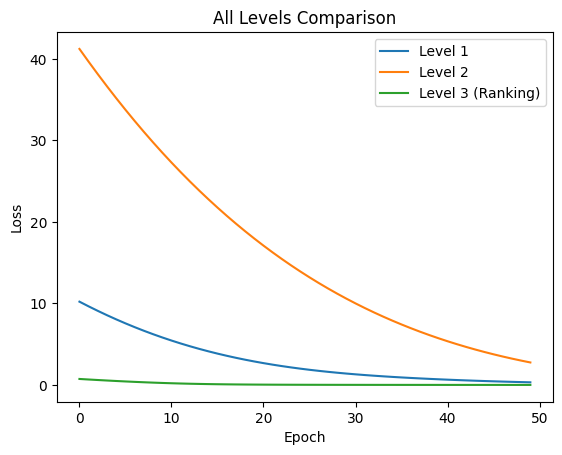

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_history, label="Level 1")
plt.plot(loss_history_v2, label="Level 2")
plt.plot(loss_history_v3, label="Level 3 (Ranking)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("All Levels Comparison")
plt.legend()
plt.show()

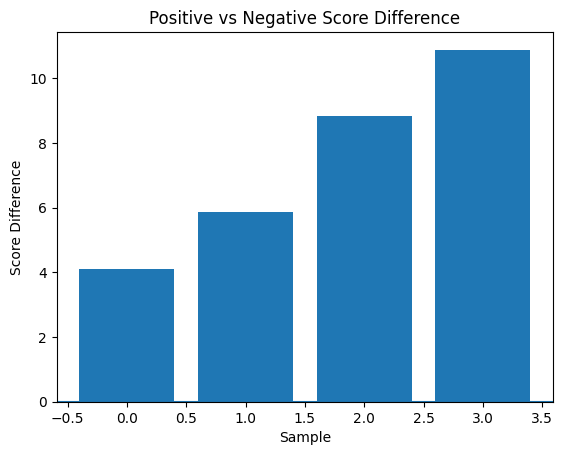

In [ ]:
diff = (pos_scores - neg_scores).detach().numpy()

plt.figure()
plt.bar(range(len(diff)), diff)
plt.axhline(0)  # boundary

plt.title("Positive vs Negative Score Difference")
plt.xlabel("Sample")
plt.ylabel("Score Difference")
plt.show()

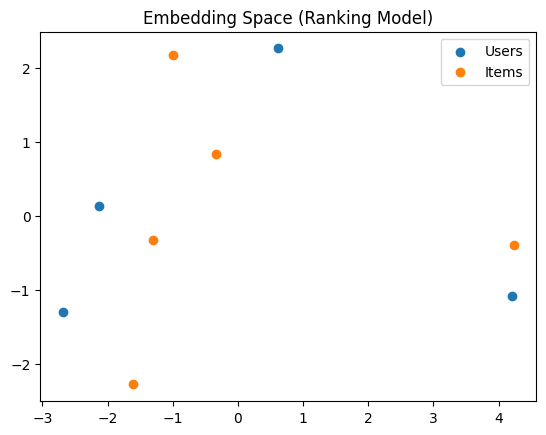

In [ ]:
from sklearn.decomposition import PCA

user_emb = model.user_embedding.weight.detach().numpy()
item_emb = model.item_embedding.weight.detach().numpy()

pca = PCA(n_components=2)

user_2d = pca.fit_transform(user_emb)
item_2d = pca.fit_transform(item_emb)

plt.figure()

plt.scatter(user_2d[:,0], user_2d[:,1], label="Users")
plt.scatter(item_2d[:,0], item_2d[:,1], label="Items")

plt.title("Embedding Space (Ranking Model)")
plt.legend()
plt.show()

In [ ]:
# ============================================
# LEVEL 4: PRODUCTION-STYLE RECOMMENDER
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import random

# -------------------------------
# 1. Interaction Data
# -------------------------------
interactions = {
    0: [0, 1],
    1: [0, 2],
    2: [1, 3],
    3: [2, 4]
}

num_users = 4
num_items = 5

# -------------------------------
# 2. Dataset Class
# -------------------------------
class RecDataset(torch.utils.data.Dataset):
    def __init__(self, interactions, num_items):
        self.data = []

        for user, items in interactions.items():
            for pos_item in items:
                self.data.append((user, pos_item))

        self.num_items = num_items
        self.interactions = interactions

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        user, pos_item = self.data[idx]

        # 🔥 Random negative sampling
        while True:
            neg_item = random.randint(0, self.num_items - 1)
            if neg_item not in self.interactions[user]:
                break

        return user, pos_item, neg_item


dataset = RecDataset(interactions, num_items)
loader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)

# -------------------------------
# 3. Model (same as Level 3)
# -------------------------------
class RecModel(nn.Module):
    def __init__(self, num_users, num_items, embed_size=8):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, embed_size)
        self.item_embedding = nn.Embedding(num_items, embed_size)

    def forward(self, user, item):
        user_vec = self.user_embedding(user)
        item_vec = self.item_embedding(item)
        return (user_vec * item_vec).sum(dim=1)


model = RecModel(num_users, num_items)

# -------------------------------
# 4. BPR Loss
# -------------------------------
def bpr_loss(pos, neg):
    return -torch.mean(torch.log(torch.sigmoid(pos - neg)))

# -------------------------------
# 5. Training Loop (BATCHED)
# -------------------------------
optimizer = optim.Adam(model.parameters(), lr=0.01)

loss_history_v4 = []

for epoch in range(50):
    total_loss = 0

    for user, pos_item, neg_item in loader:

        optimizer.zero_grad()

        pos_score = model(user, pos_item)
        neg_score = model(user, neg_item)

        loss = bpr_loss(pos_score, neg_score)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history_v4.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

Epoch 0, Loss: 0.8664
Epoch 10, Loss: 1.3152
Epoch 20, Loss: 0.9916
Epoch 30, Loss: 0.2657
Epoch 40, Loss: 0.0857


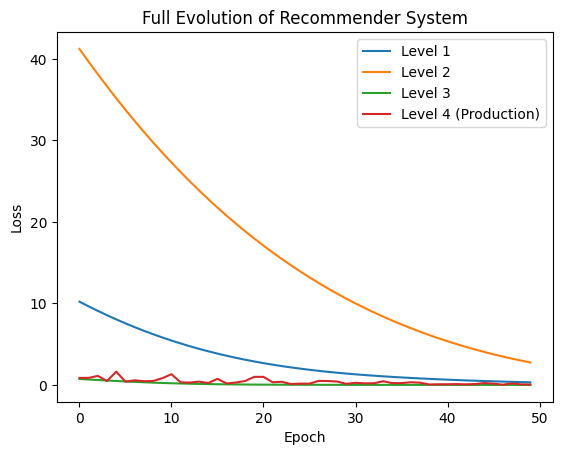

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_history, label="Level 1")
plt.plot(loss_history_v2, label="Level 2")
plt.plot(loss_history_v3, label="Level 3")
plt.plot(loss_history_v4, label="Level 4 (Production)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Full Evolution of Recommender System")
plt.legend()
plt.show()

In [ ]:
correct = 0
total = 0

for user, pos_item, neg_item in dataset:
    user = torch.tensor([user])
    pos_item = torch.tensor([pos_item])
    neg_item = torch.tensor([neg_item])

    pos_score = model(user, pos_item)
    neg_score = model(user, neg_item)

    if pos_score > neg_score:
        correct += 1

    total += 1

accuracy = correct / total

print("Ranking Accuracy:", accuracy)

Ranking Accuracy: 1.0
